<a href="https://colab.research.google.com/github/endahwulandari2005-code/aplikasidicoding/blob/main/Tugas_Data_Klasifikasi_Wulandari.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.metrics import accuracy_score # model evaluation

In [ ]:
heart_dataset = pd.read_csv("/content/heart.csv")
heart_dataset

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


Berikut adalah deskripsi untuk setiap kolom dalam dataset:

*   **Age**: Usia pasien dalam tahun.
*   **Sex**: Jenis kelamin pasien (M = Male, F = Female).
*   **ChestPainType**: Tipe nyeri dada (TA = Typical Angina, ATA = Atypical Angina, NAP = Non-Anginal Pain, ASY = Asymptomatic).
*   **RestingBP**: Tekanan darah istirahat (mm Hg).
*   **Cholesterol**: Kolesterol serum (mm/dl).
*   **FastingBS**: Gula darah puasa > 120 mg/dl (1 = True, 0 = False).
*   **RestingECG**: Hasil elektrokardiogram saat istirahat (Normal, ST, LVH).
*   **MaxHR**: Detak jantung maksimum yang dicapai.
*   **ExerciseAngina**: Angina yang diinduksi oleh olahraga (Y = Yes, N = No).
*   **Oldpeak**: Depresi ST relatif terhadap istirahat yang diinduksi oleh olahraga.
*   **ST_Slope**: Kemiringan segmen ST puncak latihan (Up = Upsloping, Flat = Flat, Down = Downsloping).
*   **HeartDisease**: Keberadaan penyakit jantung (1 = Yes, 0 = No).

In [ ]:
heart_dataset.HeartDisease.value_counts()

,count
HeartDisease,
1,508
0,410


**HeartDisease**: Keberadaan penyakit jantung (1 = Yes, 0 = No).
kemungkinan ada 508 dan tidak ada 410

Imbalance Class

In [ ]:
heart_dataset.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


##**Logistik Regression**

Logistik Regresi adalah sebuah algoritma klasifikasi yang digunakan untuk memprediksi probabilitas suatu kejadian. Meskipun namanya 'regresi', Logistik Regresi digunakan untuk masalah klasifikasi biner (dua kelas) atau multi-kelas.

kita akan mengimplementasikan Logistik Regresi sebelumnya di sel-sel seperti mWCvdaE98awr (menggunakan statsmodels) dan sNYDtoP2_Fcl (menggunakan sklearn).

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
x = heart_dataset.drop(columns= "HeartDisease")
y = heart_dataset.HeartDisease

In [ ]:
x

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up
...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat


In [ ]:
y

,HeartDisease
0,0
1,1
2,0
3,1
4,0
...,...
913,1
914,1
915,1
916,1


In [ ]:
from sklearn.model_selection import train_test_split
# split the dataset
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size= 0.3, random_state= 1)
x_train

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope
528,49,M,NAP,131,142,0,Normal,127,Y,1.5,Flat
704,50,M,ASY,150,243,0,LVH,128,N,2.6,Flat
675,57,M,NAP,150,126,1,Normal,173,N,0.2,Up
245,54,M,TA,120,171,0,Normal,137,N,2.0,Up
257,36,M,NAP,150,160,0,Normal,172,N,0.0,Up
...,...,...,...,...,...,...,...,...,...,...,...
767,54,F,NAP,108,267,0,LVH,167,N,0.0,Up
72,52,M,ASY,120,182,0,Normal,150,N,0.0,Flat
908,63,M,ASY,140,187,0,LVH,144,Y,4.0,Up
235,39,M,ATA,120,200,0,Normal,160,Y,1.0,Flat


In [ ]:
x_test

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope
900,58,M,ASY,114,318,0,ST,140,N,4.4,Down
570,56,M,ASY,128,223,0,ST,119,Y,2.0,Down
791,51,M,ASY,140,298,0,Normal,122,Y,4.2,Flat
189,53,M,ASY,180,285,0,ST,120,Y,1.5,Flat
372,63,M,ASY,185,0,0,Normal,98,Y,0.0,Up
...,...,...,...,...,...,...,...,...,...,...,...
66,45,F,ASY,132,297,0,Normal,144,N,0.0,Up
395,38,M,ASY,135,0,1,Normal,150,N,0.0,Flat
355,67,M,TA,145,0,0,LVH,125,N,0.0,Flat
277,52,M,ASY,170,223,0,Normal,126,Y,1.5,Flat


Beberapa kolom dalam data pelatihan (x_train) masih berjenis kategorikal (non-numerik), seperti 'Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', dan 'ST_Slope'. Fungsi (statsmodels.Logit) memerlukan semua input data dalam format numerik. Sehingga kita perlu secara eksplisit mengubah semua kolom dalam x_train_encoded dan x_test_encoded menjadi tipe numerik sebelum digunakan oleh model.

In [ ]:
x_train_encoded = pd.get_dummies(x_train, drop_first=True)
x_test_encoded = pd.get_dummies(x_test, drop_first=True)

# Convert all columns to float to ensure compatibility with statsmodels
x_train_encoded = x_train_encoded.astype(float)
x_test_encoded = x_test_encoded.astype(float)

model = sm.Logit(y_train, sm.add_constant(x_train_encoded))
model_result = model.fit()

model_result.summary()

Optimization terminated successfully.
         Current function value: 0.325538
         Iterations 7


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:           HeartDisease   No. Observations:                  642
Model:                          Logit   Df Residuals:                      626
Method:                           MLE   Df Model:                           15
Date:                Sun, 12 Apr 2026   Pseudo R-squ.:                  0.5290
Time:                        05:13:11   Log-Likelihood:                -209.00
converged:                       True   LL-Null:                       -443.75
Covariance Type:            nonrobust   LLR p-value:                 1.567e-90
=====================================================================================
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -2.2629      1.709     -1.324      0.185      -5.613       1.087
Age                   0.0182      0.016      1.131      0.258      -0.013       0.050
RestingBP             0.0086      0.008      1.113      0.266      -0.007       0.024
Cholesterol          -0.0047      0.001     -3.575      0.000      -0.007      -0.002
FastingBS             1.0681      0.328      3.259      0.001       0.426       1.710
MaxHR                -0.0023      0.006     -0.376      0.707      -0.015       0.010
Oldpeak               0.4315      0.138      3.138      0.002       0.162       0.701
Sex_M                 1.5668      0.345      4.542      0.000       0.891       2.243
ChestPainType_ATA    -2.0199      0.416     -4.853      0.000      -2.836      -1.204
ChestPainType_NAP    -1.8944      0.317     -5.976      0.000      -2.516      -1.273
ChestPainType_TA     -1.6032      0.528     -3.035      0.002      -2.638      -0.568
RestingECG_Normal    -0.0575      0.326     -0.176      0.860      -0.697       0.582
RestingECG_ST        -0.3167      0.414     -0.765      0.444      -1.128       0.495
ExerciseAngina_Y      0.8662      0.284      3.047      0.002       0.309       1.423
ST_Slope_Flat         1.4544      0.532      2.733      0.006       0.411       2.497
ST_Slope_Up          -0.8802      0.560     -1.571      0.116      -1.978       0.218
=====================================================================================
"""

Model ini menunjukkan bahwa beberapa faktor seperti FastingBS, Oldpeak, jenis kelamin (Sex_M), tipe nyeri dada (ChestPainType), dan angina yang diinduksi oleh olahraga (ExerciseAngina_Y), serta kemiringan ST (ST_Slope_Flat) adalah prediktor signifikan untuk HeartDisease. Cholesterol menunjukkan hubungan yang menarik (negatif namun sangat kecil). Variabel seperti Age, RestingBP, MaxHR, dan RestingECG tampaknya tidak signifikan dalam model ini.

In [ ]:
pred = model_result.predict(sm.add_constant(x_test_encoded))
pred = np.where(pred <= 0.5, 0, 1)
pred

array([1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0,
       1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0,
       0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1,
       1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0,
       0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0,
       0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1,
       0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0,
       0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0,
       0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1,
       0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0,
       1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0,
       1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0])

np.where(pred <= 0.5, 0, 1) mengonversi prediksi probabilitas menjadi kelas biner (0 atau 1). Jika probabilitas prediksi kurang dari atau sama dengan 0.5, maka dikategorikan sebagai 0 (tidak gagal bayar); jika lebih dari 0.5, dikategorikan sebagai 1 (gagal bayar).



In [ ]:
accuracy_score(y_test, pred) * 100

86.95652173913044

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:

logistic_model = LogisticRegression()

logistic_model.fit(x_train_encoded, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [ ]:
pred = logistic_model.predict(x_test_encoded)
pred

array([1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0,
       1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0,
       0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1,
       1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0,
       0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0,
       0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1,
       0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0,
       0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0,
       0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1,
       0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0,
       1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0,
       1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0])

In [ ]:
x_test1 = x_test.copy()
x_test1['Default_pred'] = pred
x_test1['Default'] = y_test
x_test1

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,Default_pred,Default
900,58,M,ASY,114,318,0,ST,140,N,4.4,Down,1,1
570,56,M,ASY,128,223,0,ST,119,Y,2.0,Down,1,1
791,51,M,ASY,140,298,0,Normal,122,Y,4.2,Flat,1,1
189,53,M,ASY,180,285,0,ST,120,Y,1.5,Flat,1,1
372,63,M,ASY,185,0,0,Normal,98,Y,0.0,Up,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
66,45,F,ASY,132,297,0,Normal,144,N,0.0,Up,0,0
395,38,M,ASY,135,0,1,Normal,150,N,0.0,Flat,1,1
355,67,M,TA,145,0,0,LVH,125,N,0.0,Flat,1,1
277,52,M,ASY,170,223,0,Normal,126,Y,1.5,Flat,1,1


Menambahkan hasil prediksi model ke dalam dataset testing asli untuk perbandingan dengan nilai default yang sebenarnya

In [ ]:
accuracy_score(y_test, pred) * 100

88.40579710144928

##**KNN**



KNN (K-Nearest Neighbors) adalah algoritma pembelajaran mesin non-parametrik yang dapat digunakan untuk tugas klasifikasi dan regresi. Prinsip kerjanya cukup intuitif:

1.  **Memilih K**: Anda perlu menentukan nilai `K`, yang merupakan jumlah 'tetangga' terdekat yang akan dipertimbangkan.
2.  **Menghitung Jarak**: Untuk setiap titik data baru yang ingin diklasifikasikan atau diregresi, algoritma akan menghitung jaraknya (misalnya, jarak Euclidean) ke semua titik data di set pelatihan.
3.  **Menemukan Tetangga Terdekat**: Setelah jarak dihitung, algoritma akan memilih `K` titik data dari set pelatihan yang memiliki jarak terpendek ke titik data baru.
4.  **Klasifikasi atau Regresi**:
    *   **Untuk Klasifikasi**: Titik data baru akan diberi label kelas yang paling sering muncul di antara `K` tetangga terdekat.
    *   **Untuk Regresi**: Nilai titik data baru akan dihitung berdasarkan rata-rata (atau median) dari nilai `K` tetangga terdekat.

**Kelebihan KNN**:
*   Sederhana dan mudah diimplementasikan.
*   Tidak ada asumsi tentang distribusi data (non-parametrik).
*   Dapat digunakan untuk masalah klasifikasi dan regresi.

**Kekurangan KNN**:
*   Sensitif terhadap skala fitur dan data yang tidak seimbang.
*   Membutuhkan komputasi yang tinggi untuk dataset besar karena perlu menghitung jarak ke setiap titik data.
*   Pemilihan nilai `K` yang tepat bisa menjadi tantangan.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
knn_model = KNeighborsClassifier(n_neighbors= 7)
knn_model.fit(x_train_encoded, y_train)

KNeighborsClassifier(n_neighbors=7)

In [ ]:
y_pred = knn_model.predict(x_test_encoded)
accuracy_score(y_test, y_pred) * 100

69.56521739130434

In [ ]:
y_pred

array([0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0,
       1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0,
       0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1,
       0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0,
       0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1,
       0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0,
       1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1,
       0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1,
       1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0,
       1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0,
       1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1])

In [ ]:
neighbors_list = [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21]
train_accuracy_list, test_accuracy_list = [], []

for neighbor_num in neighbors_list:
    knn_model = KNeighborsClassifier(n_neighbors= neighbor_num)
    knn_model.fit(x_train_encoded, y_train)

    train_pred = knn_model.predict(x_train_encoded)
    test_pred = knn_model.predict(x_test_encoded)
    train_acc_score = accuracy_score(y_train, train_pred) * 100
    test_acc_score = accuracy_score(y_test, test_pred) * 100

    train_accuracy_list.append(train_acc_score)
    test_accuracy_list.append(test_acc_score)
    print("Neighbors_num: {0} --> Accuracy on Test Set: {1} %".format(neighbor_num, np.round(test_acc_score, 2)))

Neighbors_num: 1 --> Accuracy on Test Set: 67.03 %
Neighbors_num: 3 --> Accuracy on Test Set: 68.84 %
Neighbors_num: 5 --> Accuracy on Test Set: 72.46 %
Neighbors_num: 7 --> Accuracy on Test Set: 69.57 %
Neighbors_num: 9 --> Accuracy on Test Set: 68.84 %
Neighbors_num: 11 --> Accuracy on Test Set: 67.75 %
Neighbors_num: 13 --> Accuracy on Test Set: 67.39 %
Neighbors_num: 15 --> Accuracy on Test Set: 67.39 %
Neighbors_num: 17 --> Accuracy on Test Set: 67.39 %
Neighbors_num: 19 --> Accuracy on Test Set: 68.48 %
Neighbors_num: 21 --> Accuracy on Test Set: 68.48 %


In [ ]:
performance_df = pd.DataFrame({
    'Neighbors_num' : neighbors_list,
    'Train Accuracy': train_accuracy_list,
    'Test Accuracy': test_accuracy_list
})

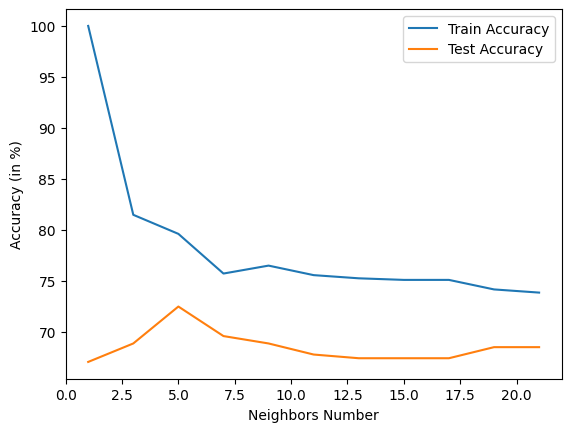

In [ ]:
plt.plot(
    performance_df['Neighbors_num'] ,performance_df['Train Accuracy'],
    performance_df['Neighbors_num'] ,performance_df['Test Accuracy']
)
plt.xlabel("Neighbors Number")
plt.ylabel("Accuracy (in %)")
plt.legend(['Train Accuracy', 'Test Accuracy'])

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[ 74  35]
 [ 49 118]]
              precision    recall  f1-score   support

           0       0.60      0.68      0.64       109
           1       0.77      0.71      0.74       167

    accuracy                           0.70       276
   macro avg       0.69      0.69      0.69       276
weighted avg       0.70      0.70      0.70       276



##**Decision Tree**

Decision Tree memodelkan keputusan dalam bentuk struktur pohon, di mana setiap "node" internal mewakili pengujian pada atribut, setiap "cabang" mewakili hasil pengujian, dan setiap "node daun" mewakili keputusan atau label kelas.

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn import preprocessing
from sklearn.model_selection import GridSearchCV, StratifiedKFold

In [ ]:
classifier = DecisionTreeClassifier()
classifier.fit(x_train_encoded, y_train)

DecisionTreeClassifier()

In [ ]:
y_pred = classifier.predict(x_test_encoded)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[ 77  32]
 [ 42 125]]
              precision    recall  f1-score   support

           0       0.65      0.71      0.68       109
           1       0.80      0.75      0.77       167

    accuracy                           0.73       276
   macro avg       0.72      0.73      0.72       276
weighted avg       0.74      0.73      0.73       276



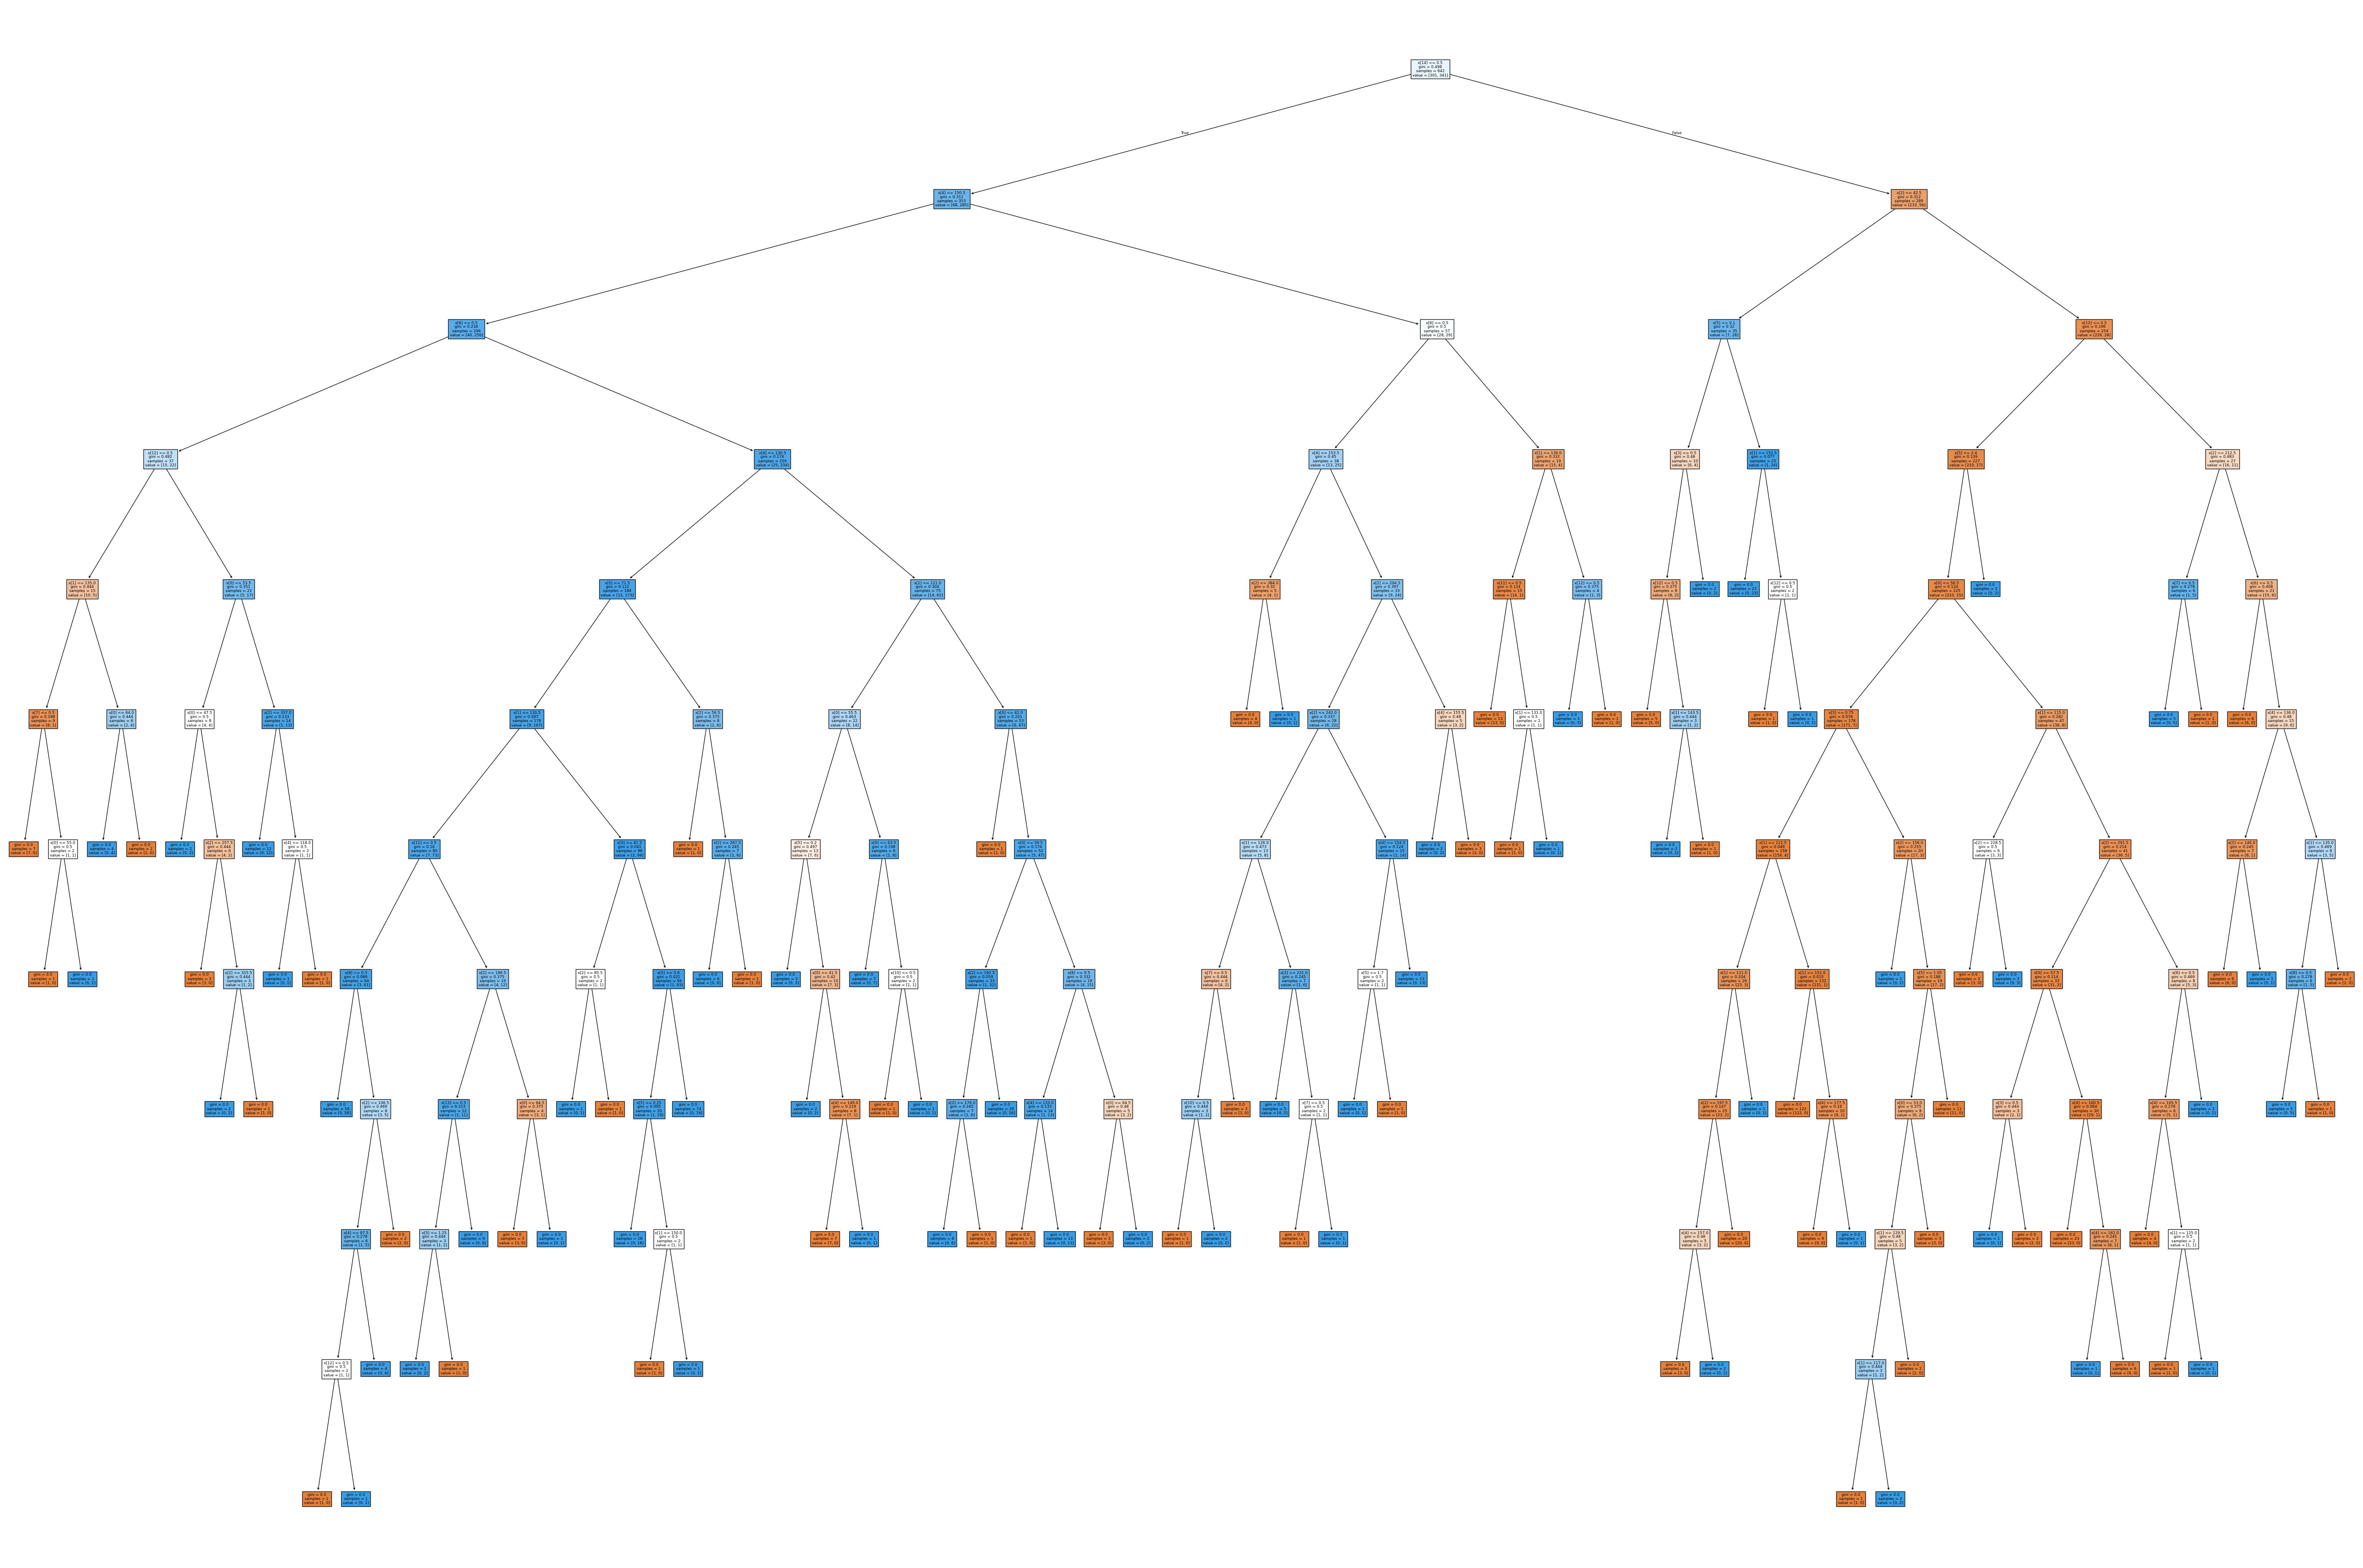

In [ ]:
from sklearn.tree import plot_tree
plt.figure(figsize = (75,50))
plot_tree(classifier.fit(x_train_encoded, y_train), filled=True)
plt.show()

In [ ]:
# import modul

from sklearn.ensemble import RandomForestClassifier

# inisialisasi modul

rfc = RandomForestClassifier(random_state=0) #randomstate=0 digunakan agar hasil eksperimen tetap konsisten

# melatih model (proses dimana model belajar memetakan pola dari daftar xtrain... terhadap label targetnya ytrain)

rfc.fit(x_train_encoded, y_train)

RandomForestClassifier(random_state=0)

In [ ]:
# Predict the Test set results

y_pred = rfc.predict(x_test_encoded)
y_pred

array([1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0,
       1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0,
       0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1,
       1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0,
       0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0,
       0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1,
       0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0,
       0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0,
       0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0,
       1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0,
       1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0])

In [ ]:
#evaluasi akurasi
from sklearn.metrics import accuracy_score

print('Model accuracy score with 10 decision-trees : {0:0.4f}'. format(accuracy_score(y_test, y_pred)))

Model accuracy score with 10 decision-trees : 0.8804


tujuanya: menghitung seberapa akurat prediksi model (y_pred) dibandingkan dnegan data asli (x_pred)

hasilnya: skor akurasi sebesar 0.8804 (88,04%)

In [ ]:
# define the parameter list
max_depth_tree_list = np.arange(1, 20, 2)
tree_params_list = {
    'max_depth': max_depth_tree_list,
    'criterion': ['log_loss', 'gini', 'entropy'],
}

In [ ]:
grid_search = GridSearchCV(
    estimator= DecisionTreeClassifier(),
    param_grid= tree_params_list,
    cv= StratifiedKFold(n_splits= 3),
    scoring= 'precision'
)
grid_search.fit(x_train_encoded, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=3, random_state=None, shuffle=False),
             estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['log_loss', 'gini', 'entropy'],
                         'max_depth': array([ 1,  3,  5,  7,  9, 11, 13, 15, 17, 19])},
             scoring='precision')

GridSearchCV akan secara otomatis melatih model decision tree berkali-kali menggunakan setiap kombinasi parameter yang ada di tree_params_list untuk menemukan yang paling optimal bagi data tersebut.

In [ ]:
grid_search.best_estimator_

DecisionTreeClassifier(criterion='log_loss', max_depth=np.int64(3))

In [ ]:
best_model = grid_search.best_estimator_

In [ ]:
y_best = best_model.predict(x_test_encoded)
y_best

array([1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0,
       1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0,
       0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1,
       1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0,
       0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0,
       0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1,
       0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0,
       0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1,
       0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0,
       1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1,
       0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0])

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
print(confusion_matrix(y_test, y_best))
print(classification_report(y_test, y_best))

[[ 84  25]
 [ 22 145]]
              precision    recall  f1-score   support

           0       0.79      0.77      0.78       109
           1       0.85      0.87      0.86       167

    accuracy                           0.83       276
   macro avg       0.82      0.82      0.82       276
weighted avg       0.83      0.83      0.83       276



Laporan Klasifikasi
- Precision : keakuratan prediksi positif. Kelas 1 memiliki presisi 0.85 (85%)
- Recall: kemmapuan model menemukan semua data positif. Kelas 1 memiliki recall 0.87 (87%).
- F1-Score : rata-rata harmonik antara presisi dan recall. Digunakan unutk melihat keseimbangan keduanya.
- Support: Jumlah data asli untuk setiap kelas (109 data kelas 0 dan 167 data kelas 1)

**Akurasi Keseluruhan**
0.83 (83%). Artinnya secara keseluruhan model berhasil menebak dengan benar 83% dari total 276 data uji.

##**Support Vector Machine**



Support Vector Machine (SVM) adalah algoritma pembelajaran mesin yang kuat dan serbaguna, mampu melakukan klasifikasi, regresi, dan deteksi *outlier*. Tujuan utama SVM adalah menemukan *hyperplane* terbaik yang secara optimal memisahkan kelas-kelas dalam data (untuk klasifikasi) atau memodelkan hubungan antara fitur dan target (untuk regresi).

**Prinsip Kerja (untuk Klasifikasi)**:
1.  **Mencari *Hyperplane* Optimal**: SVM mencari *hyperplane* (garis dalam 2D, bidang dalam 3D, atau *hyperplane* dalam dimensi yang lebih tinggi) yang memisahkan kelas-kelas data dengan margin terbesar. Margin adalah jarak antara *hyperplane* dan titik data terdekat dari setiap kelas (disebut *support vectors*).
2.  ***Support Vectors***: Titik-titik data yang paling dekat dengan *hyperplane* dan berperan penting dalam menentukan posisi dan orientasi *hyperplane* disebut *support vectors*. Hanya *support vectors* ini yang memengaruhi *hyperplane*, membuat SVM cukup efisien.
3.  **Penanganan Data Non-Linear (*Kernel Trick*)**: Jika data tidak dapat dipisahkan secara linear, SVM menggunakan 'kernel trick'. Ini melibatkan pemetaan data ke ruang dimensi yang lebih tinggi di mana pemisahan linear mungkin dilakukan. Fungsi *kernel* yang umum meliputi *Linear*, *Polynomial*, *Radial Basis Function (RBF) atau Gaussian*, dan *Sigmoid*.

**Kelebihan SVM**:
*   Efektif di ruang dimensi tinggi.
*   Efektif ketika jumlah fitur lebih besar dari jumlah sampel.
*   Menggunakan subset poin pelatihan (yaitu, *support vectors*) dalam fungsi keputusan, sehingga sangat hemat memori.
*   Serbaguna: Fungsi *kernel* yang berbeda dapat ditentukan untuk fungsi keputusan yang berbeda.

**Kekurangan SVM**:
*   Tidak cocok untuk dataset besar karena waktu pelatihan yang lama.
*   Sensitif terhadap *outlier* dan *noise*.
*   Pemilihan fungsi *kernel* dan parameter yang tepat bisa menjadi tantangan dan membutuhkan eksperimen.
*   Sulit untuk menginterpretasikan hasil, terutama dengan fungsi *kernel* non-linear.

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn import datasets
from sklearn.metrics import confusion_matrix


In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv('/content/heart.csv')
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


Cek data
jika hasilnya tidak ada nul --> lanjut

jika ada nul --> perlu dibersihkan lagi

In [ ]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


pisahkan fitur(x) dan target (y)

In [ ]:
X = df.drop('HeartDisease', axis=1)
y = df['HeartDisease']

**split data**

pemisahan data menjadi training (data pelatihan) dan testing (data pengujian)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

Normalisasi
karena SVM sensitif terhadap skala
dengan mneggunakan one-hot encoding unutk kolom kategorikal, yang penting agar model dapat memprosesnya.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Apply one-hot encoding to handle categorical features
X_train_encoded = pd.get_dummies(X_train, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, drop_first=True)

# Scale the encoded numerical features
X_train = scaler.fit_transform(X_train_encoded)
X_test = scaler.transform(X_test_encoded)

In [ ]:
from sklearn.svm import SVC

model = SVC(kernel='rbf')  # terbaik biasanya rbf
model.fit(X_train, y_train)

SVC()

In [ ]:
#predisksi
y_pred = model.predict(X_test)

In [ ]:
#Evaluasi
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Akurasi:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Akurasi: 0.875
[[67 10]
 [13 94]]
              precision    recall  f1-score   support

           0       0.84      0.87      0.85        77
           1       0.90      0.88      0.89       107

    accuracy                           0.88       184
   macro avg       0.87      0.87      0.87       184
weighted avg       0.88      0.88      0.88       184



Berdasarkan hasil evaluasi model Support Vector Machine (SVM) yang telah dijalankan, berikut adalah kesimpulannya:

**Akurasi**: Model mencapai akurasi sebesar 87.5%. Ini berarti 87.5% dari prediksi yang dilakukan oleh model sudah benar.

**Confusion Matrix**:

**True Negative** (TN): 67 (Model benar memprediksi tidak ada penyakit jantung)
**False Positive (FP)**: 10 (Model salah memprediksi ada penyakit jantung, padahal tidak)
**False Negative (FN)**: 13 (Model salah memprediksi tidak ada penyakit jantung, padahal ada)
**True Positive (TP)**: 94 (Model benar memprediksi ada penyakit jantung)
Classification Report:

**Class 0 (Tidak ada penyakit jantung)**:
**Precision (Presisi)**: 0.84 (Dari semua yang diprediksi tidak ada penyakit jantung, 84% benar)
**Recall (Sensitivitas)**: 0.87 (Dari semua yang sebenarnya tidak ada penyakit jantung, 87% berhasil dideteksi)
**F1-Score**: 0.85 (Rata-rata harmonik presisi dan recall)
**Class 1 (Ada penyakit jantung)**:
**Precision (Presisi)**: 0.90 (Dari semua yang diprediksi ada penyakit jantung, 90% benar)
**Recall (Sensitivitas)**: 0.88 (Dari semua yang sebenarnya ada penyakit jantung, 88% berhasil dideteksi)
**F1-Score**: 0.89 (Rata-rata harmonik presisi dan recall)


Secara keseluruhan, model SVM ini menunjukkan kinerja yang sangat baik dengan akurasi tinggi dan kemampuan yang seimbang dalam memprediksi kedua kelas (ada atau tidak ada penyakit jantung), meskipun sedikit lebih baik dalam memprediksi adanya penyakit jantung (Class 1) berdasarkan nilai presisi dan recall-nya.